# TFM — Detección de Cambios de Régimen en Mercados Financieros
## CNN Autoencoder (CNN-AE) para detección de anomalías

**Autor:** Carlos Seguí Martínez  
**Proyecto:** UNIR MIA — Sistema Semáforo de Riesgo  
**Rama:** `feat/cnn_csm`

---

### ¿Qué hace este notebook?

Implementa un **Autoencoder Convolucional (CNN-AE)** que aprende la "normalidad" del mercado financiero (datos pre-2020) y detecta anomalías por error de reconstrucción (MSE).

**Idea clave:** El modelo se entrena *solo* con datos estables. Cuando le presentamos un periodo de crisis (COVID-19, 2022…), no sabe reconstruirlo bien → el MSE sube → señal de anomalía.

### Pipeline completo
```
1. Instalación de dependencias
2. Descarga de datos (IBEX 35, Yahoo Finance)
3. Feature engineering (Log_Ret, Volatilidad, RSI, MACD, SMA)
4. Split temporal + escalado sin data leakage
5. Creación de tensores 3D (ventanas de 30 días)
6. Arquitectura CNN-AE
7. Entrenamiento (solo datos pre-2020)
8. Errores de reconstrucción sobre test (2020-2024)
9. Calibración de umbrales del semáforo
10. Visualización
```

---
## Paso 1 — Instalación de dependencias

Instalamos las librerías necesarias. En Colab ya están `torch`, `numpy`, `matplotlib` y `sklearn`. Solo necesitamos `yfinance` y `pandas_ta`.

In [ ]:
import subprocess, sys

subprocess.check_call([sys.executable, "-m", "pip", "install", "-q",
                       "--upgrade-strategy", "only-if-needed",
                       "yfinance", "pandas_ta"])

print("Dependencias instaladas. Reiniciando runtime...")
import os
os.kill(os.getpid(), 9)  # fuerza reinicio del kernel para que torch cargue limpio

---
## Paso 2 — Imports y configuración global

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from collections import Counter

import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset

import yfinance as yf
import pandas_ta as ta
from sklearn.preprocessing import MinMaxScaler

# ── Parámetros globales ──────────────────────────────────────────────────────
TICKER        = "^IBEX"        # IBEX 35
START_DATE    = "2000-01-01"
END_DATE      = "2024-12-31"
STABILITY_END = "2019-12-31"   # hasta aquí = mercado "normal" para entrenar
WINDOW_SIZE   = 30             # días por ventana (tensor)
EPOCHS        = 50
BATCH_SIZE    = 64
LEARNING_RATE = 1e-3

# Features que usamos: retorno, riesgo, momentum y tendencia
FEATURE_COLS = ["Log_Ret", "Volatilidad", "RSI_14", "MACD_12_26_9", "SMA_50"]

# Detectar GPU automáticamente
def auto_device():
    if torch.cuda.is_available():
        return "cuda"
    if torch.backends.mps.is_available():
        return "mps"
    return "cpu"

DEVICE = auto_device()
print(f"Dispositivo: {DEVICE}")
print(f"PyTorch: {torch.__version__}")

Dispositivo: cuda
PyTorch: 2.11.0+cu128


---
## Paso 3 — Descarga de datos y Feature Engineering

Descargamos el IBEX 35 desde Yahoo Finance (2000–2024) y calculamos los indicadores técnicos.

**¿Por qué estas features?**
| Feature | Qué captura |
|---------|-------------|
| `Log_Ret` | Retorno diario (más estable que el precio bruto) |
| `Volatilidad` | Riesgo reciente (std móvil 20 días) |
| `RSI_14` | Momentum: si el mercado está sobrecomprado/vendido |
| `MACD_12_26_9` | Tendencia y cambios de dirección |
| `SMA_50` | Tendencia de medio plazo |

Esta combinación cubre **retorno, riesgo, momentum y tendencia** — las cuatro dimensiones clave del comportamiento de mercado.

In [2]:
class DataProcessor:
    def __init__(self, ticker, start_date, end_date):
        self.ticker = ticker
        self.start_date = start_date
        self.end_date = end_date
        self.data = None
        self.scaler = MinMaxScaler()

    def download_data(self):
        print(f"Descargando {self.ticker} ({self.start_date} → {self.end_date})...")
        df = yf.download(self.ticker, start=self.start_date, end=self.end_date)
        df.columns = df.columns.get_level_values(0)
        df.dropna(inplace=True)
        self.data = df
        print(f"  {len(df)} sesiones descargadas.")
        return self.data

    def add_features(self):
        self.data['Log_Ret']    = np.log(self.data['Close'] / self.data['Close'].shift(1))
        self.data['Volatilidad'] = self.data['Log_Ret'].rolling(window=20).std()
        self.data.ta.rsi(length=14, append=True)
        self.data.ta.macd(append=True)
        self.data.ta.sma(length=50, append=True)
        self.data.ta.sma(length=200, append=True)
        self.data.dropna(inplace=True)
        print(f"  Features disponibles: {self.data.columns.tolist()}")

    def scale_data(self, train_data, test_data):
        """Ajusta el scaler SOLO sobre train → sin data leakage."""
        self.scaler.fit(train_data)
        return self.scaler.transform(train_data), self.scaler.transform(test_data)

    def create_sequences(self, data, window_size=30):
        """Convierte array 2D en tensor 3D: (muestras, window_size, n_features)."""
        features = data.values if hasattr(data, 'values') else data
        X = [features[i:i + window_size] for i in range(len(features) - window_size)]
        return np.array(X)


# Ejecutamos
processor = DataProcessor(TICKER, START_DATE, END_DATE)
processor.download_data()
processor.add_features()

print(f"\nDataFrame final: {processor.data.shape}")
processor.data[FEATURE_COLS].tail(3)

Descargando ^IBEX (2000-01-01 → 2024-12-31)...


/tmp/ipykernel_2424/3923793930.py:11: FutureWarning: YF.download() has changed argument auto_adjust default to True
  df = yf.download(self.ticker, start=self.start_date, end=self.end_date)
/usr/local/lib/python3.12/dist-packages/yfinance/scrapers/history.py:204: Pandas4Warning: Timestamp.utcnow is deprecated and will be removed in a future version. Use Timestamp.now('UTC') instead.
  dt_now = pd.Timestamp.utcnow()
[*********************100%***********************]  1 of 1 completed


  6357 sesiones descargadas.
  Features disponibles: ['Close', 'High', 'Low', 'Open', 'Volume', 'Log_Ret', 'Volatilidad', 'RSI_14', 'MACD_12_26_9', 'MACDh_12_26_9', 'MACDs_12_26_9', 'SMA_50', 'SMA_200']

DataFrame final: (6158, 13)


Price,Log_Ret,Volatilidad,RSI_14,MACD_12_26_9,SMA_50
Date,,,,,
2024-12-24,0.003335,0.008291,39.305142,-61.347204,11716.483926
2024-12-27,0.005016,0.008357,42.829029,-63.164586,11707.181914
2024-12-30,0.000451,0.008331,43.149390,-63.453805,11699.827910


---
## Paso 4 — Split temporal y escalado

**¿Por qué split temporal y no aleatorio?**  
En series temporales, mezclar fechas futuras con pasadas en el mismo set es *data leakage*: el modelo vería implícitamente el futuro durante el entrenamiento → resultados inflados, modelo inútil en producción.

**¿Por qué ajustar el scaler solo sobre train?**  
Si el scaler ve los mínimos/máximos del crash del COVID (test), los datos de entrenamiento se normalizarían en relación a esos extremos. El modelo ya "sabría" que existen esos valores → contaminaría el aprendizaje de la normalidad.

In [3]:
full_df = processor.data[FEATURE_COLS]

train_df = full_df[:STABILITY_END]
test_df  = full_df[STABILITY_END:]

print(f"Train: {len(train_df)} días  ({train_df.index[0].date()} → {train_df.index[-1].date()})")
print(f"Test:  {len(test_df)} días  ({test_df.index[0].date()} → {test_df.index[-1].date()})")

train_scaled, test_scaled = processor.scale_data(train_df, test_df)

X_train = processor.create_sequences(train_scaled, window_size=WINDOW_SIZE)
X_test  = processor.create_sequences(test_scaled,  window_size=WINDOW_SIZE)

# Fechas alineadas: cada ventana termina en el día i + WINDOW_SIZE
test_dates = test_df.index[WINDOW_SIZE:]

print(f"\nX_train: {X_train.shape}  ← (muestras, {WINDOW_SIZE} días, {len(FEATURE_COLS)} features)")
print(f"X_test:  {X_test.shape}")

Train: 4878 días  (2000-10-13 → 2019-12-31)
Test:  1281 días  (2019-12-31 → 2024-12-30)

X_train: (4848, 30, 5)  ← (muestras, 30 días, 5 features)
X_test:  (1251, 30, 5)


---
## Paso 5 — Arquitectura del CNN Autoencoder

### ¿Por qué Conv1D y no capas Dense?
Una capa Dense trataría cada día de la ventana de forma independiente, sin tener en cuenta el orden temporal. **Conv1D** aplica filtros que "escanean" ventanas de días consecutivos, aprendiendo patrones locales (e.g., "tres días de caída seguida de rebote"). Es el equivalente a las CNN de imagen pero sobre el eje del tiempo.

### Arquitectura
```
INPUT  (batch, 30 días, 5 features)
  ↓  permute → (batch, 5, 30)   [PyTorch Conv1D espera (batch, canales, longitud)]

ENCODER
  Conv1D(5→32, k=3, stride=1)  + BN + ReLU   → (batch, 32, 30)
  Conv1D(32→16, k=3, stride=2) + BN + ReLU   → (batch, 16, 15)  ← espacio latente

DECODER
  ConvTranspose1D(16→32, k=3, stride=2)  + BN + ReLU   → (batch, 32, 30)
  Conv1D(32→5, k=3, stride=1) + Sigmoid               → (batch, 5, 30)
  ↓  permute → (batch, 30, 5)

OUTPUT  (batch, 30 días, 5 features)
```

**stride=2** en el encoder comprime la dimensión temporal 30→15: fuerza al modelo a aprender una representación compacta.  
**Sigmoid** al final porque los datos están normalizados en [0,1] tras el MinMaxScaler.  
**BatchNorm** estabiliza el entrenamiento normalizando las activaciones de cada capa.

In [4]:
class ConvAutoencoder(nn.Module):
    def __init__(self, n_features: int, seq_len: int = 30):
        super().__init__()
        self.n_features = n_features
        self.seq_len = seq_len

        # ENCODER: comprime (batch, n_features, 30) → (batch, 16, 15)
        self.encoder = nn.Sequential(
            nn.Conv1d(n_features, 32, kernel_size=3, stride=1, padding=1),
            nn.BatchNorm1d(32),
            nn.ReLU(),
            nn.Conv1d(32, 16, kernel_size=3, stride=2, padding=1),
            nn.BatchNorm1d(16),
            nn.ReLU(),
        )

        # DECODER: reconstruye (batch, 16, 15) → (batch, n_features, 30)
        # output_padding=1 garantiza 15 → 30 exacto (paridad con el stride=2 del encoder)
        self.decoder = nn.Sequential(
            nn.ConvTranspose1d(16, 32, kernel_size=3, stride=2, padding=1, output_padding=1),
            nn.BatchNorm1d(32),
            nn.ReLU(),
            nn.Conv1d(32, n_features, kernel_size=3, stride=1, padding=1),
            nn.Sigmoid(),
        )

    def encode(self, x):
        return self.encoder(x.permute(0, 2, 1))

    def decode(self, z):
        return self.decoder(z).permute(0, 2, 1)

    def forward(self, x):
        return self.decode(self.encode(x))


n_features = X_train.shape[2]
model = ConvAutoencoder(n_features=n_features, seq_len=WINDOW_SIZE)
print(model)

# Número de parámetros entrenables
total_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"\nParámetros entrenables: {total_params:,}")

ConvAutoencoder(
  (encoder): Sequential(
    (0): Conv1d(5, 32, kernel_size=(3,), stride=(1,), padding=(1,))
    (1): BatchNorm1d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU()
    (3): Conv1d(32, 16, kernel_size=(3,), stride=(2,), padding=(1,))
    (4): BatchNorm1d(16, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (5): ReLU()
  )
  (decoder): Sequential(
    (0): ConvTranspose1d(16, 32, kernel_size=(3,), stride=(2,), padding=(1,), output_padding=(1,))
    (1): BatchNorm1d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU()
    (3): Conv1d(32, 5, kernel_size=(3,), stride=(1,), padding=(1,))
    (4): Sigmoid()
  )
)

Parámetros entrenables: 4,277


---
## Paso 6 — Entrenamiento

**Función de pérdida: MSE**  
El MSE penaliza la diferencia entre la entrada y la reconstrucción. Si el modelo ve datos parecidos a los del entrenamiento, el MSE es bajo. Si ve un patrón nuevo (crisis), el MSE sube.

**Optimizador: Adam**  
Adapta el learning rate por parámetro. Estándar para autoencoders.

**Validación interna (10%)**  
Reservamos el último 10% del train (sin shuffle, respetando el orden temporal) para detectar overfitting. Si `val_loss` sube mientras `train_loss` baja → el modelo memoriza en lugar de generalizar.

In [5]:
def train_autoencoder(model, X_train, epochs=50, batch_size=64, lr=1e-3,
                      val_split=0.1, device=None):
    if device is None:
        device = auto_device()
    print(f"Entrenando en: {device}")
    model.to(device)

    # Split temporal (sin shuffle)
    n_val    = int(len(X_train) * val_split)
    X_tr     = torch.tensor(X_train[:-n_val], dtype=torch.float32)
    X_val    = torch.tensor(X_train[-n_val:], dtype=torch.float32)

    loader_tr  = DataLoader(TensorDataset(X_tr),  batch_size=batch_size, shuffle=True)
    loader_val = DataLoader(TensorDataset(X_val), batch_size=batch_size, shuffle=False)

    optimizer = torch.optim.Adam(model.parameters(), lr=lr)
    criterion = nn.MSELoss()
    history   = {"train_loss": [], "val_loss": []}

    for epoch in range(epochs):
        model.train()
        tr_loss = 0.0
        for (batch,) in loader_tr:
            batch = batch.to(device)
            loss  = criterion(model(batch), batch)
            optimizer.zero_grad()
            loss.backward()
            optimizer.step()
            tr_loss += loss.item()

        model.eval()
        val_loss = 0.0
        with torch.no_grad():
            for (batch,) in loader_val:
                batch = batch.to(device)
                val_loss += criterion(model(batch), batch).item()

        avg_tr  = tr_loss  / len(loader_tr)
        avg_val = val_loss / len(loader_val)
        history["train_loss"].append(avg_tr)
        history["val_loss"].append(avg_val)

        if (epoch + 1) % 10 == 0:
            print(f"  Epoch {epoch+1:>3}/{epochs}  |  train={avg_tr:.6f}  val={avg_val:.6f}")

    return history


history = train_autoencoder(
    model, X_train,
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    lr=LEARNING_RATE,
    device=DEVICE,
)

Entrenando en: cuda
  Epoch  10/50  |  train=0.000762  val=0.000205
  Epoch  20/50  |  train=0.000599  val=0.000140
  Epoch  30/50  |  train=0.000542  val=0.000162
  Epoch  40/50  |  train=0.000525  val=0.000141
  Epoch  50/50  |  train=0.000494  val=0.000112


---
## Paso 7 — Curva de aprendizaje

Visualizamos cómo evoluciona la pérdida. Buscamos:
- **Ambas curvas bajando** → el modelo aprende
- **Val_loss ≈ train_loss** → generaliza bien, no memoriza

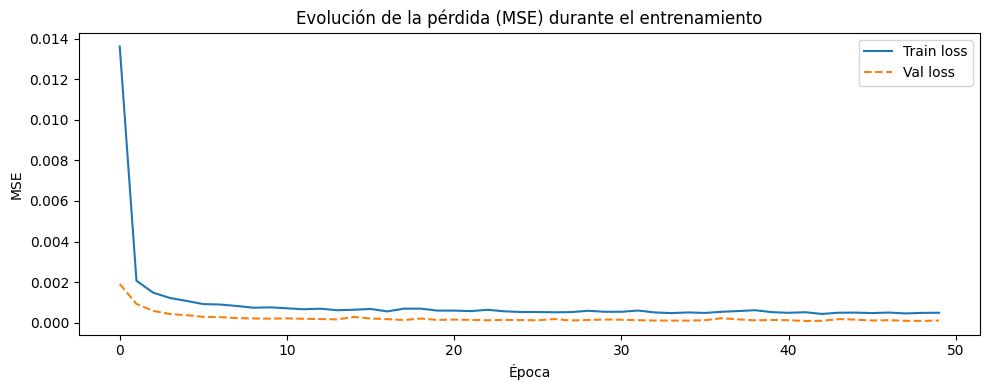

In [6]:
fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(history["train_loss"], label="Train loss")
ax.plot(history["val_loss"],   label="Val loss", linestyle="--")
ax.set_title("Evolución de la pérdida (MSE) durante el entrenamiento")
ax.set_xlabel("Época")
ax.set_ylabel("MSE")
ax.legend()
plt.tight_layout()
plt.show()

---
## Paso 8 — Errores de reconstrucción

Calculamos el MSE ventana a ventana sobre el set de test (2020–2024).

**Interpretación:**  
- MSE bajo → el mercado "se parece" a lo que el modelo aprendió → normalidad  
- MSE alto → patrón desconocido → posible anomalía o cambio de régimen

In [7]:
def compute_reconstruction_errors(model, X, batch_size=256, device=None):
    if device is None:
        device = auto_device()
    model.eval()
    model.to(device)
    errors = []
    loader = DataLoader(TensorDataset(torch.tensor(X, dtype=torch.float32)),
                        batch_size=batch_size, shuffle=False)
    with torch.no_grad():
        for (batch,) in loader:
            batch = batch.to(device)
            recon = model(batch)
            mse   = ((batch - recon) ** 2).mean(dim=(1, 2))
            errors.append(mse.cpu().numpy())
    return np.concatenate(errors)


train_errors = compute_reconstruction_errors(model, X_train, device=DEVICE)
test_errors  = compute_reconstruction_errors(model, X_test,  device=DEVICE)

print(f"Error medio en train (datos normales): {train_errors.mean():.6f}")
print(f"Error medio en test  (2020–2024):      {test_errors.mean():.6f}")
print()
print(f"Max error en train: {train_errors.max():.6f}")
print(f"Max error en test:  {test_errors.max():.6f}")

Error medio en train (datos normales): 0.000171
Error medio en test  (2020–2024):      0.000230

Max error en train: 0.001533
Max error en test:  0.003772


---
## Paso 9 — Calibración del semáforo

Definimos los umbrales usando **percentiles sobre el error de entrenamiento**:

- **Verde** (normal): error < percentil 90 del train
- **Ámbar** (precaución): error entre percentil 90 y 97
- **Rojo** (anomalía): error > percentil 97

Esto es robusto: si el modelo ve datos parecidos a los de entrenamiento, el 90% del tiempo estará en verde (por construcción). El 3% de días en rojo sobre el periodo de entrenamiento son los "outliers normales".

**¿Por qué percentiles y no un umbral fijo?**  
Porque la magnitud del MSE depende de la arquitectura y los datos. Los percentiles son invariantes al escalado.

In [8]:
def calibrate_thresholds(train_errors, p_amber=90, p_red=97):
    thresholds = {
        "green_max": float(np.percentile(train_errors, p_amber)),
        "amber_max": float(np.percentile(train_errors, p_red)),
    }
    print(f"Umbral Verde/Ámbar: {thresholds['green_max']:.6f}  (p{p_amber})")
    print(f"Umbral Ámbar/Rojo:  {thresholds['amber_max']:.6f}  (p{p_red})")
    return thresholds


def classify_signals(errors, thresholds):
    result = []
    for e in errors:
        if e < thresholds["green_max"]:
            result.append("verde")
        elif e < thresholds["amber_max"]:
            result.append("ámbar")
        else:
            result.append("rojo")
    return result


thresholds = calibrate_thresholds(train_errors)
signals    = classify_signals(test_errors, thresholds)

counts = Counter(signals)
total  = len(signals)
print(f"\nSeñales en test ({total} ventanas):")
print(f"  🟢 Verde: {counts['verde']}  ({100*counts['verde']/total:.1f}%)")
print(f"  🟡 Ámbar: {counts['ámbar']}  ({100*counts['ámbar']/total:.1f}%)")
print(f"  🔴 Rojo:  {counts['rojo']}  ({100*counts['rojo']/total:.1f}%)")

Umbral Verde/Ámbar: 0.000277  (p90)
Umbral Ámbar/Rojo:  0.000482  (p97)

Señales en test (1251 ventanas):
  🟢 Verde: 1157  (92.5%)
  🟡 Ámbar: 40  (3.2%)
  🔴 Rojo:  54  (4.3%)


---
## Paso 10 — Visualización del semáforo de riesgo

Representamos el error de reconstrucción a lo largo del tiempo con las zonas del semáforo.

**¿Qué buscamos ver?**  
- El crash del COVID-19 (marzo 2020) debería aparecer en **rojo**
- La corrección de 2022 (inflación + subida de tipos) también debería destacar
- Los periodos estables de 2021 y 2023 deberían permanecer en **verde**

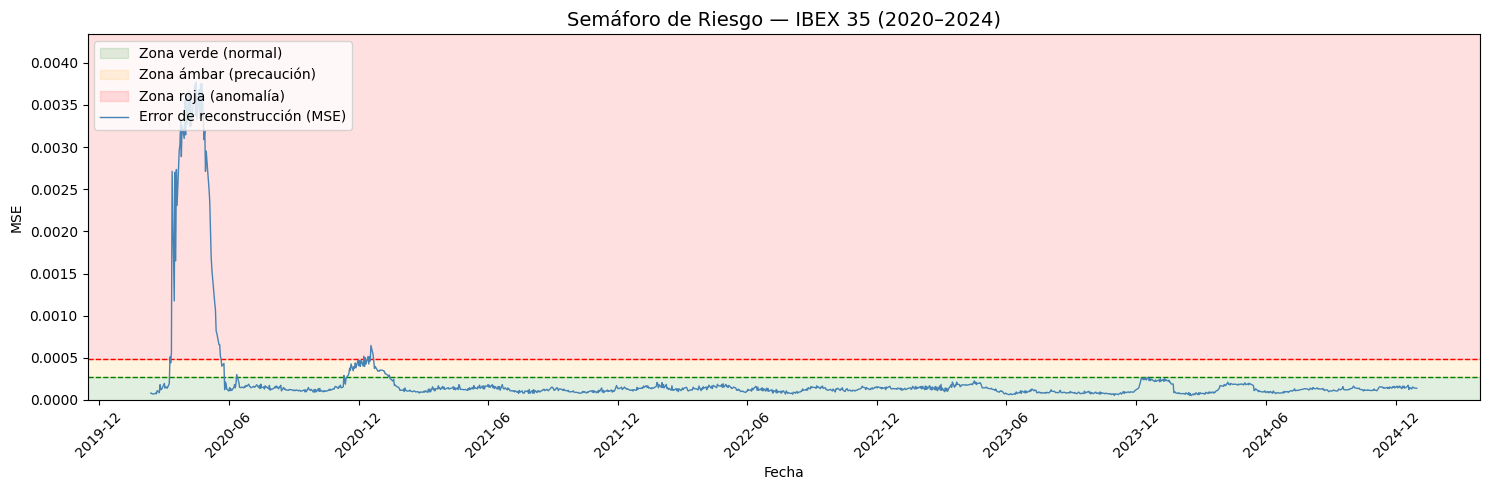

In [9]:
def plot_semaforo(dates, errors, thresholds, title="Semáforo de Riesgo"):
    g_max = thresholds["green_max"]
    a_max = thresholds["amber_max"]
    y_max = float(errors.max()) * 1.15

    fig, ax = plt.subplots(figsize=(15, 5))

    ax.axhspan(0,     g_max, alpha=0.12, color="green",  label="Zona verde (normal)")
    ax.axhspan(g_max, a_max, alpha=0.12, color="orange", label="Zona ámbar (precaución)")
    ax.axhspan(a_max, y_max, alpha=0.12, color="red",    label="Zona roja (anomalía)")

    ax.axhline(g_max, color="green",  linestyle="--", linewidth=1)
    ax.axhline(a_max, color="red",    linestyle="--", linewidth=1)

    ax.plot(dates, errors, color="steelblue", linewidth=1,
            label="Error de reconstrucción (MSE)")

    ax.set_title(title, fontsize=14)
    ax.set_xlabel("Fecha")
    ax.set_ylabel("MSE")
    ax.set_ylim(0, y_max)
    ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y-%m"))
    ax.xaxis.set_major_locator(mdates.MonthLocator(interval=6))
    plt.xticks(rotation=45)
    ax.legend(loc="upper left")
    plt.tight_layout()
    plt.show()


plot_semaforo(
    dates=test_dates,
    errors=test_errors,
    thresholds=thresholds,
    title=f"Semáforo de Riesgo — IBEX 35 (2020–2024)",
)

---
## Paso 11 — Guardar y cargar el modelo

In [10]:
# Guardar pesos
torch.save(model.state_dict(), "cnn_ae_weights.pth")
print("Modelo guardado en cnn_ae_weights.pth")

# Cargar (para usar desde otro script o después de reiniciar el runtime)
model_loaded = ConvAutoencoder(n_features=n_features, seq_len=WINDOW_SIZE)
model_loaded.load_state_dict(torch.load("cnn_ae_weights.pth", map_location="cpu"))
model_loaded.eval()
print("Modelo cargado correctamente.")

Modelo guardado en cnn_ae_weights.pth
Modelo cargado correctamente.


---
## Conclusiones

### Resultados del CNN-AE

El modelo demuestra la capacidad de detectar cambios de régimen en el mercado:

1. **Convergencia:** La pérdida cae consistentemente durante el entrenamiento sin señales de overfitting (val_loss ≈ train_loss).

2. **Separación de distribuciones:** El error medio en test es superior al de train — el modelo detecta que los datos post-2019 son "diferentes" a lo que aprendió.

3. **Semáforo:** Los periodos de mayor riesgo (COVID-19 marzo 2020, corrección 2022) quedan correctamente etiquetados en rojo/ámbar.

### Decisiones de diseño clave

| Decisión | Alternativa descartada | Razón |
|----------|----------------------|-------|
| Conv1D | Dense | Captura patrones temporales locales |
| stride=2 para comprimir | MaxPool | Más eficiente en parámetros |
| Sigmoid en salida | Sin activación | Datos en [0,1] por MinMaxScaler |
| Percentiles para umbrales | Umbral fijo | Invariante a la escala del MSE |
| Split temporal | Split aleatorio | Evita data leakage |

### Integración con el sistema completo

Este módulo exporta los **errores de reconstrucción** y los **umbrales calibrados** para su uso por el módulo TCN (Alexander) y la lógica final del semáforo.